In [1]:
import jax.numpy as np
import numpy as onp
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from gwfast.gwfastGlobals import MTSUN_SI

plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=12)

from gwfast.lensing_utils_alt import \
    get_agn_lens_angles, PML_time_delay_magnification

# %matplotlib widget

# $y$ wrt $\theta_\text{E}$, keeping $R_\text{orbit}$ constant

In [49]:
n = 1000
shape = (n, n)

R_orbit = 100
dL = 1 # Gpc

def Dls_wrt_y_and_R_orbit(y, R_orbit, rs=1):
    return np.sqrt(np.square(R_orbit)+np.power(rs*y,4)) / rs - rs * np.square(y)

Dls_min = Dls_wrt_y_and_rorbit(1,R_orbit)
beta_max = np.sqrt(2*Dls_min)

# src_pos_array = np.array([
#     y * np.sqrt(2 * Dls_wrt_y_and_rorbit(y, R_orbit)) / R_orbit
#     for y in np.geomspace(0.02, 0.99, n)
# ])

src_pos_array = np.logspace(-2, 0, n)
src_pos_array = src_pos_array * np.sqrt(2 * Dls_wrt_y_and_rorbit(src_pos_array, R_orbit)) / R_orbit

M_lz_array    = np.logspace( np.log10(3e3),  np.log10(7e6), n)

src_pos_mesh, M_lz_mesh = np.meshgrid(src_pos_array, M_lz_array, indexing='xy')

theta_E, beta, lens_src_mass = get_agn_lens_angles(
    M_lz_mesh, R_orbit,
    src_pos_mesh, dL,
)
time_delay, _, _ = PML_time_delay_magnification(beta_src=beta, theta_E=theta_E)
time_delay_SI = - time_delay * lens_src_mass * MTSUN_SI

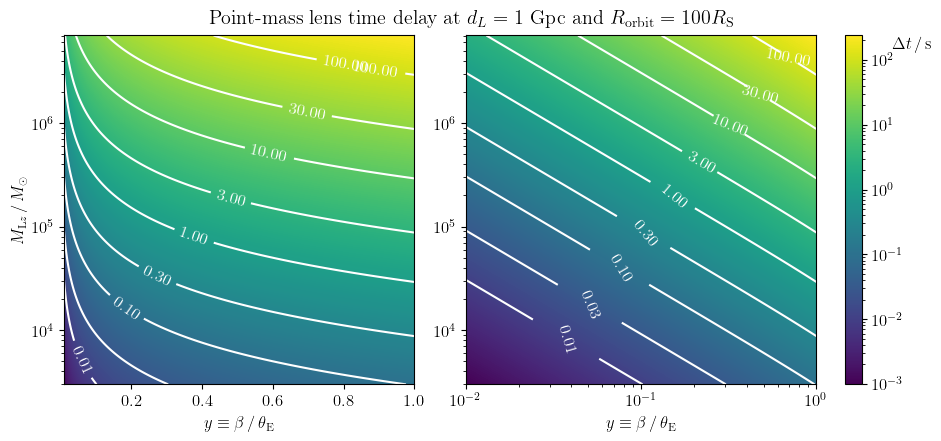

In [77]:
time_delay_levels = [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100]

nice_positions_right = [[float(pos), float(M_lz)] for pos, M_lz in zip(
    np.logspace(np.log10(3e-2), np.log10(7e-1), len(time_delay_levels)),
    np.logspace(np.log10(8e3 ), np.log10(4e6 ), len(time_delay_levels))
)]

nice_positions_left = [[float(pos), float(M_lz)] for pos, M_lz in zip(
    np.linspace(0.05, 0.9, len(time_delay_levels)),
    np.logspace(np.log10(5e3), np.log10(5e6), len(time_delay_levels))
)]

nice_positions = [nice_positions_left, nice_positions_right]

fig, axes = plt.subplots(1, 2, figsize=(9.3, 4.3), constrained_layout=True)
for ax, nice_pos in zip(axes, nice_positions):
    im = ax.pcolormesh(
        src_pos_array * R_orbit / beta_max,
        M_lz_array,
        time_delay_SI,
        norm=LogNorm()
    )
    contour = ax.contour(
        src_pos_array * R_orbit / beta_max,
        M_lz_array,
        time_delay_SI,
        levels=time_delay_levels,
        colors='white'
    )

    ax.set_yscale('log')
    ax.set_xlabel(r'$y \equiv \beta\,/\,\theta_{\rm E}$')
    ax.tick_params(axis='both', which='both', direction='out')
    ax.set_xlim(0.01, 1)
    ax.clabel(contour, inline=True, fmt='%1.2f', colors='white', manual=nice_pos)

axes[1].set_xscale('log')

fig.suptitle(r"Point-mass lens time delay at $d_L=1$ Gpc and $R_{\rm orbit} = 100 R_{\rm S}$")

axes[0].set_ylabel(r'$M_{{\rm L}z}\,/\,M_{\odot}$')
cbar = fig.colorbar(im, ax=axes[1])
cbar.set_label(r'$\Delta t\,/\,{\rm s}$', labelpad=20, loc='top', rotation=0)

# $y$ wrt $\theta_\text{E}$, keeping $D_{\ell s}$ constant

In [45]:
n = 1000
shape = (n, n)

Dls = 100
dL = 1 # Gpc

def R_orbit_wrt_y_and_Dls(y, Dls, rs=1):
    return np.sqrt(np.square(Dls) + 2*rs*Dls*np.square(y))

Dls = 100
R_orbit_max = R_orbit_wrt_y_and_Dls(1, 100)

# src_pos_array = np.array([
#     y * np.sqrt(2 * Dls_wrt_y_and_rorbit(y, R_orbit)) / R_orbit
#     for y in np.geomspace(0.02, 0.99, n)
# ])

src_pos_array = np.logspace(-2, 0, n)
src_pos_array = src_pos_array * np.sqrt(2 * Dls) / R_orbit_wrt_y_and_Dls(src_pos_array, Dls)

M_lz_array    = np.logspace( np.log10(3e3),  np.log10(7e6), n)

src_pos_mesh, M_lz_mesh = np.meshgrid(src_pos_array, M_lz_array, indexing='xy')

theta_E, beta, lens_src_mass = get_agn_lens_angles(
    M_lz_mesh, R_orbit,
    src_pos_mesh, dL,
)
time_delay, _, _ = PML_time_delay_magnification(beta_src=beta, theta_E=theta_E)
time_delay_SI = - time_delay * lens_src_mass * MTSUN_SI

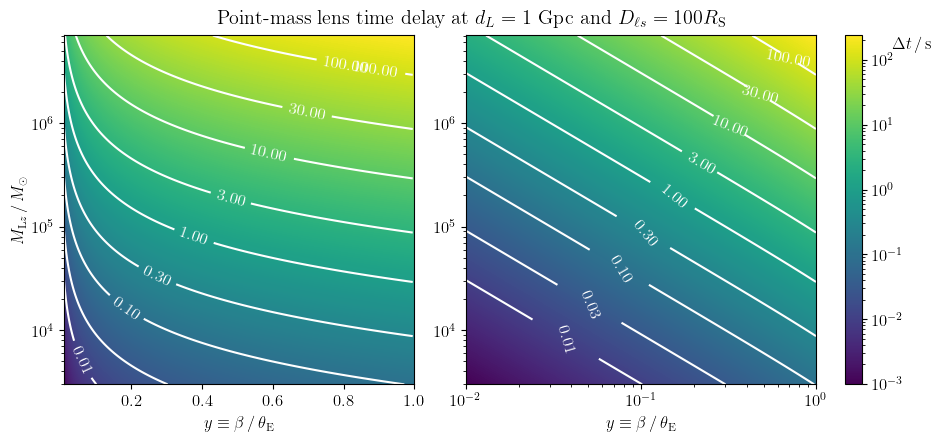

In [ ]:
time_delay_levels = [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100]

nice_positions_right = [[float(pos), float(M_lz)] for pos, M_lz in zip(
    np.logspace(np.log10(3e-2), np.log10(7e-1), len(time_delay_levels)),
    np.logspace(np.log10(8e3 ), np.log10(4e6 ), len(time_delay_levels))
)]

nice_positions_left = [[float(pos), float(M_lz)] for pos, M_lz in zip(
    np.linspace(0.05, 0.9, len(time_delay_levels)),
    np.logspace(np.log10(5e3), np.log10(5e6), len(time_delay_levels))
)]

nice_positions = [nice_positions_left, nice_positions_right]

fig, axes = plt.subplots(1, 2, figsize=(9.3, 4.3), constrained_layout=True)
for ax, nice_pos in zip(axes, nice_positions):
    im = ax.pcolormesh(
        src_pos_array * R_orbit_wrt_y_and_Dls(src_pos_array, Dls) / np.sqrt(2 * Dls),
        M_lz_array,
        time_delay_SI,
        norm=LogNorm()
    )
    contour = ax.contour(
        src_pos_array * R_orbit_wrt_y_and_Dls(src_pos_array, Dls) / np.sqrt(2 * Dls),
        M_lz_array,
        time_delay_SI,
        levels=time_delay_levels,
        colors='white'
    )

    ax.set_yscale('log')
    ax.set_xlabel(r'$y \equiv \beta\,/\,\theta_{\rm E}$')
    ax.tick_params(axis='both', which='both', direction='out')
    ax.set_xlim(0.01, 1)
    ax.clabel(contour, inline=True, fmt='%1.2f', colors='white', manual=nice_pos)

# scatter_y = [n[1] for n in nice_positions_left]
# scatter_x = [n[0] for n in nice_positions_left]
# axes[0].scatter(scatter_x, scatter_y, c="white")

# scatter_y = [n[1] for n in nice_positions_right]
# scatter_x = [n[0] for n in nice_positions_right]
# axes[1].scatter(scatter_x, scatter_y, c="white")

axes[1].set_xscale('log')

fig.suptitle(r"Point-mass lens time delay at $d_L=1$ Gpc and $D_{\ell s} = 100 R_{\rm S}$")

axes[0].set_ylabel(r'$M_{{\rm L}z}\,/\,M_{\odot}$')
cbar = fig.colorbar(im, ax=axes[1])
cbar.set_label(r'$\Delta t\,/\,{\rm s}$', labelpad=20, loc='top', rotation=0)

# EoF